# 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# 2. Загрузка датасета и первичный просмотр

In [2]:
# Загружаем встроенный датасет breast cancer
data = load_breast_cancer()

# Формируем DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Объединяем в один DataFrame для удобства анализа
df = X.copy()
df['target'] = y

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о датасете:")
print(df.info())

Размер датасета: (569, 31)

Первые 5 строк:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

# 3. Проверка пропусков и типов признаков

In [3]:
print("Количество пропусков по столбцам:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

print("Общее количество пропусков:", df.isnull().sum().sum())

print("\nТипы данных:")
display(df.dtypes.value_counts())

Количество пропусков по столбцам:


,0


Общее количество пропусков: 0

Типы данных:


,count
float64,30
int64,1


# 4. Описательная статистика

In [4]:
print("Описательная статистика признаков:")
display(df.describe())

Описательная статистика признаков:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


# 5. График распределения классов

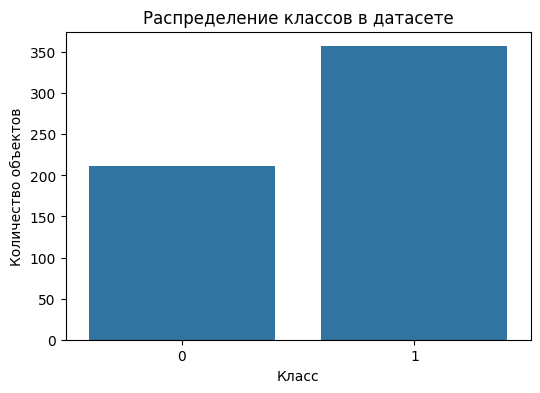

Распределение классов:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Распределение классов в датасете')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

print("Распределение классов:")
print(df['target'].value_counts())

# 6. Тепловая карта корреляций

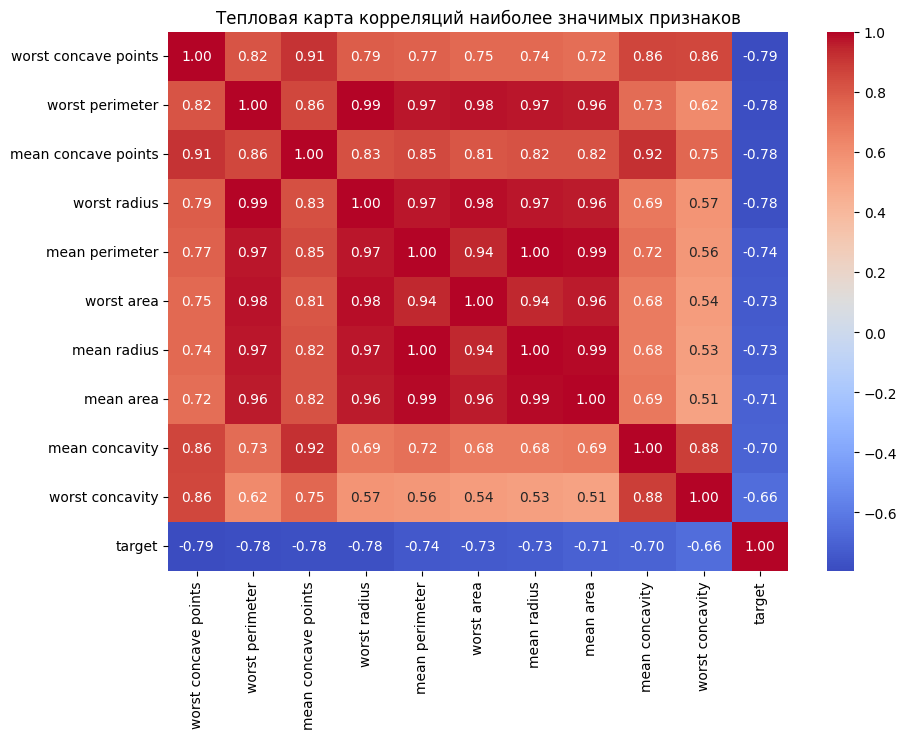

In [6]:
corr_with_target = df.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
top_features = corr_with_target.head(10).index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[top_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта корреляций наиболее значимых признаков')
plt.show()

# 7. Разделение на обучающую и тестовую выборки

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)


# 8. Создание моделей

In [9]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

# 9. Обучение моделей и расчет accuracy

In [10]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Модель': name,
        'Accuracy': acc
    })

    print(f"\nМодель: {name}")
    print(f"Accuracy: {acc:.4f}")


Модель: Random Forest
Accuracy: 0.9561

Модель: Extra Trees
Accuracy: 0.9561

Модель: AdaBoost
Accuracy: 0.9649

Модель: Gradient Boosting
Accuracy: 0.9561


# 10. Сводная таблица результатов

In [11]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(results_df)

,Модель,Accuracy
2,AdaBoost,0.964912
0,Random Forest,0.956140
1,Extra Trees,0.956140
3,Gradient Boosting,0.956140


# 11. Диаграмма сравнения моделей

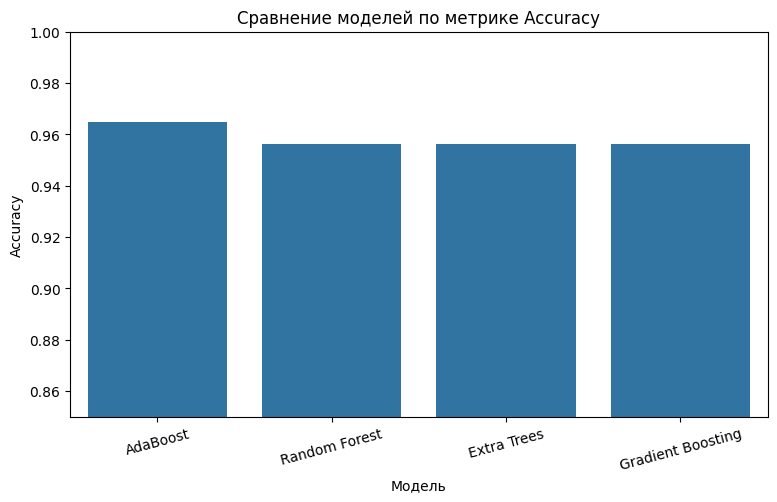

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x='Модель', y='Accuracy')
plt.title('Сравнение моделей по метрике Accuracy')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.show()

# 12. Подробный отчет по лучшей модели

In [13]:
best_model_name = results_df.iloc[0]['Модель']
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

print("Лучшая модель:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

Лучшая модель: AdaBoost

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.90      0.95        42
      benign       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# 13. Матрица ошибок для лучшей модели

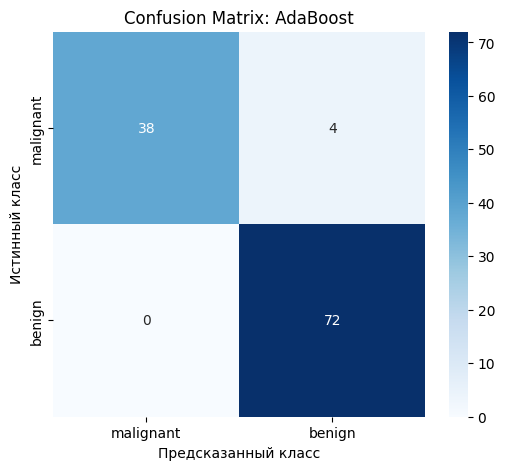

In [14]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# 14. Важность признаков для лучшей модели

,Признак,Важность
21,worst texture,0.103736
27,worst concave points,0.097796
13,area error,0.089573
1,mean texture,0.055377
14,smoothness error,0.053636
24,worst smoothness,0.050706
4,mean smoothness,0.049165
5,mean compactness,0.048533
28,worst symmetry,0.044982
20,worst radius,0.042250


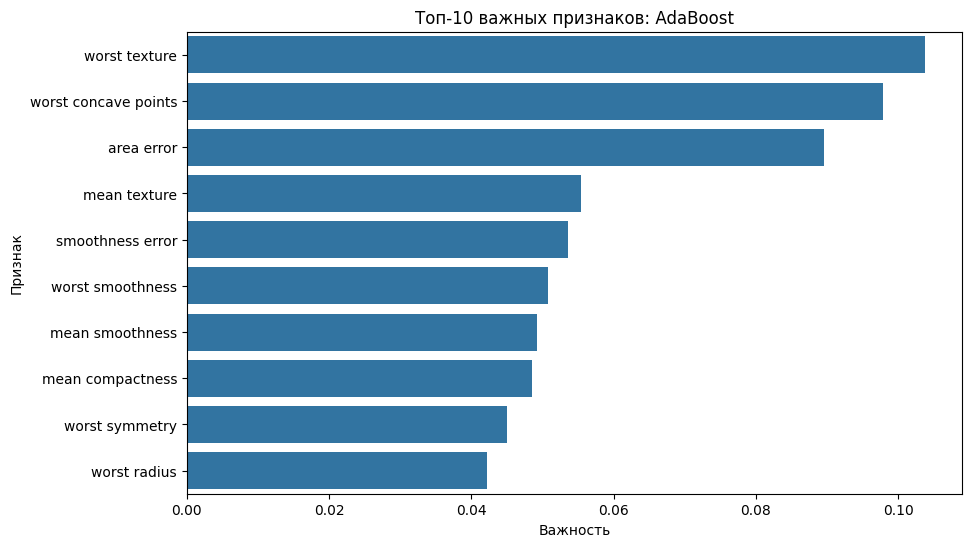

In [15]:
importances = pd.DataFrame({
    'Признак': X.columns,
    'Важность': best_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

display(importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Важность', y='Признак')
plt.title(f'Топ-10 важных признаков: {best_model_name}')
plt.show()

# 15. Матрицы ошибок сразу для всех моделей

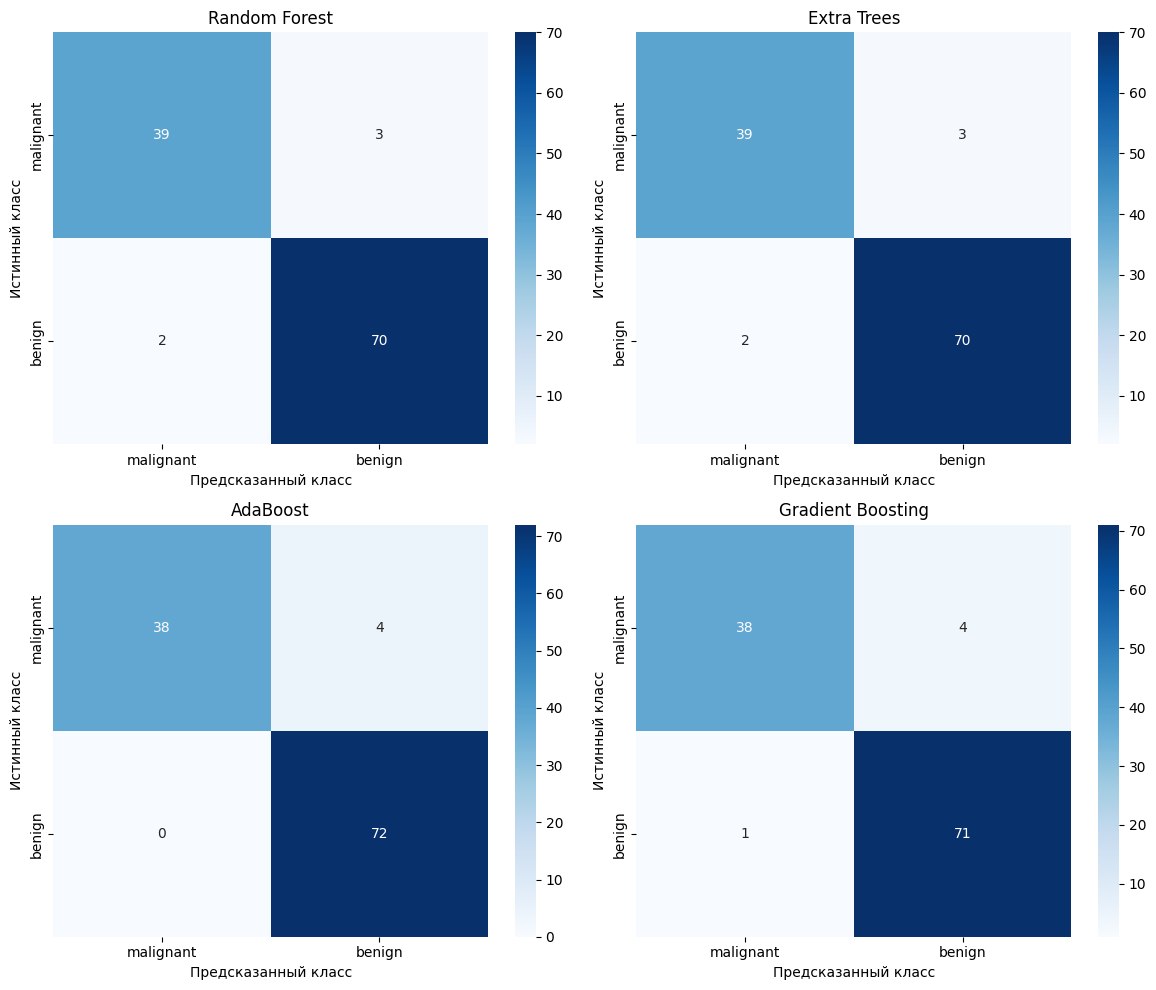

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=data.target_names,
                yticklabels=data.target_names,
                ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Предсказанный класс')
    axes[i].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()